# Diabetes Prediction — Exploratory Data Analysis

In this notebook, we explore the **Pima Indians Diabetes** dataset to understand the data, find patterns, and identify features that influence diabetes diagnosis.

**Dataset**: 768 female patients of Pima Indian heritage, aged 21+, with 8 medical predictor variables and 1 binary target (diabetic or not).

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline


## 2. Load Data

In [ ]:
df = pd.read_csv("data/diabetes.csv")
print(f"Dataset shape: {df.shape}")
df.head(10)


Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 3. Dataset Overview

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe().round(2)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [ ]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


## 4. Missing / Invalid Values Analysis

Several columns use **0** as a placeholder for missing values. For example, a `Glucose` or `BloodPressure` of 0 is biologically impossible.

In [ ]:
# Columns where 0 is not a valid value
zero_invalid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Count of 0 values (likely missing):")
print("-" * 35)
for col in zero_invalid:
    count = (df[col] == 0).sum()
    pct = count / len(df) * 100
    print(f"{col:25s}: {count:3d} ({pct:.1f}%)")


Count of 0 values (likely missing):
-----------------------------------
Glucose                  :   5 (0.7%)
BloodPressure            :  35 (4.6%)
SkinThickness            : 227 (29.6%)
Insulin                  : 374 (48.7%)
BMI                      :  11 (1.4%)


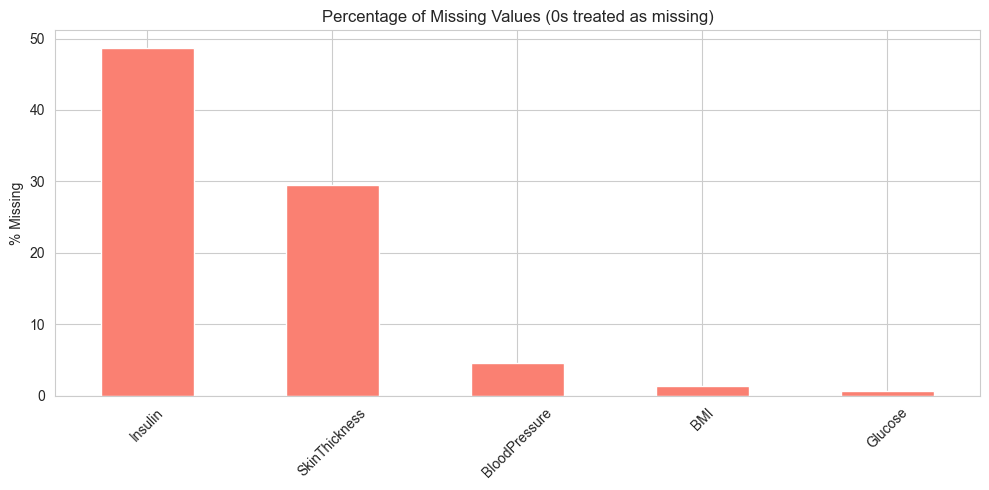

In [ ]:
# Visualize missing value pattern
df_missing = df.copy()
for col in zero_invalid:
    df_missing[col] = df_missing[col].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
missing_pct = (df_missing.isnull().sum() / len(df_missing) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct.plot(kind="bar", color="salmon", ax=ax)
ax.set_title("Percentage of Missing Values (0s treated as missing)")
ax.set_ylabel("% Missing")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Target Variable Distribution

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_71523/1516930707.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df, palette="Set2", ax=axes[0])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_71523/1516930707.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])


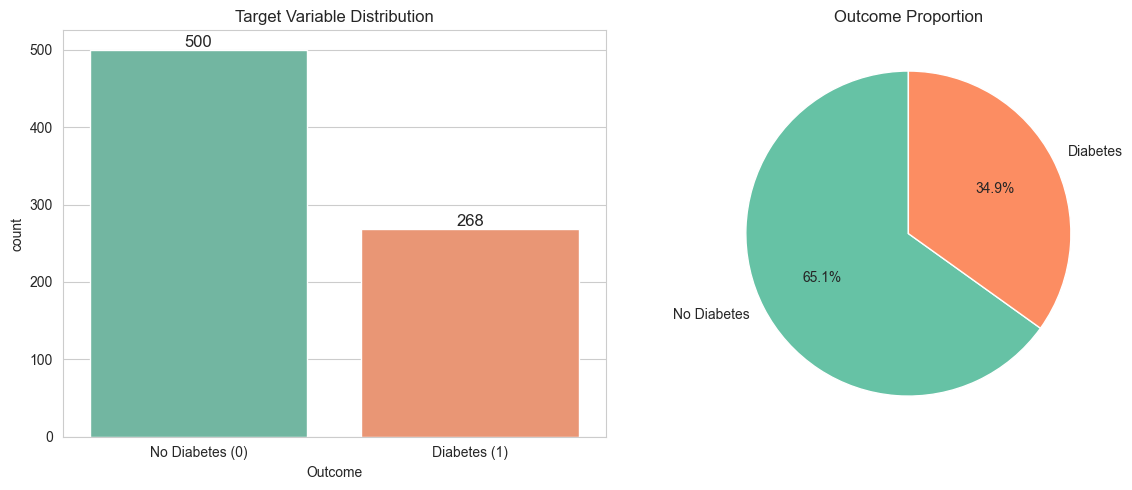


Class balance:
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetes rate: 34.9%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(x="Outcome", data=df, palette="Set2", ax=axes[0])
axes[0].set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])
axes[0].set_title("Target Variable Distribution")

# Add counts on bars
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=12)

# Pie chart
df["Outcome"].value_counts().plot.pie(
    labels=["No Diabetes", "Diabetes"],
    autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62"],
    startangle=90,
    ax=axes[1],
)
axes[1].set_ylabel("")
axes[1].set_title("Outcome Proportion")

plt.tight_layout()
plt.show()

print(f"\nClass balance:")
print(df["Outcome"].value_counts())
print(f"\nDiabetes rate: {df['Outcome'].mean():.1%}")


## 6. Univariate Analysis — Feature Distributions

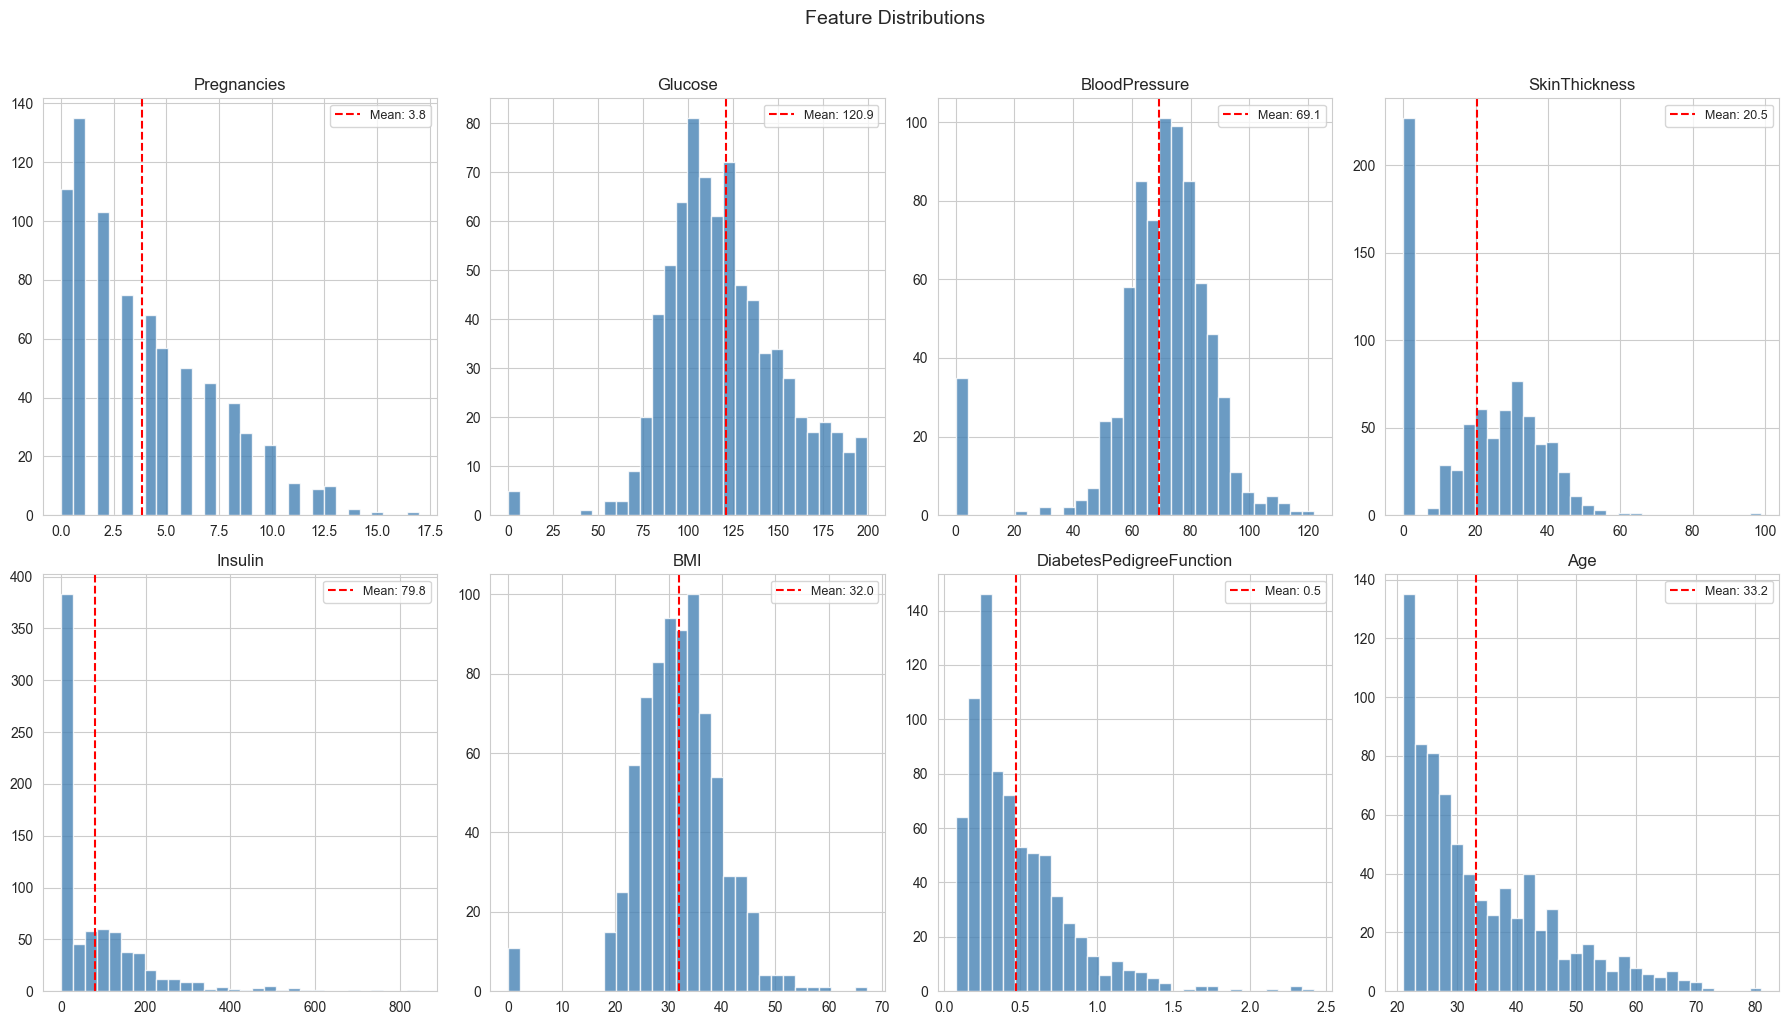

In [ ]:
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(col)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.1f}")
    axes[i].legend(fontsize=9)

plt.suptitle("Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


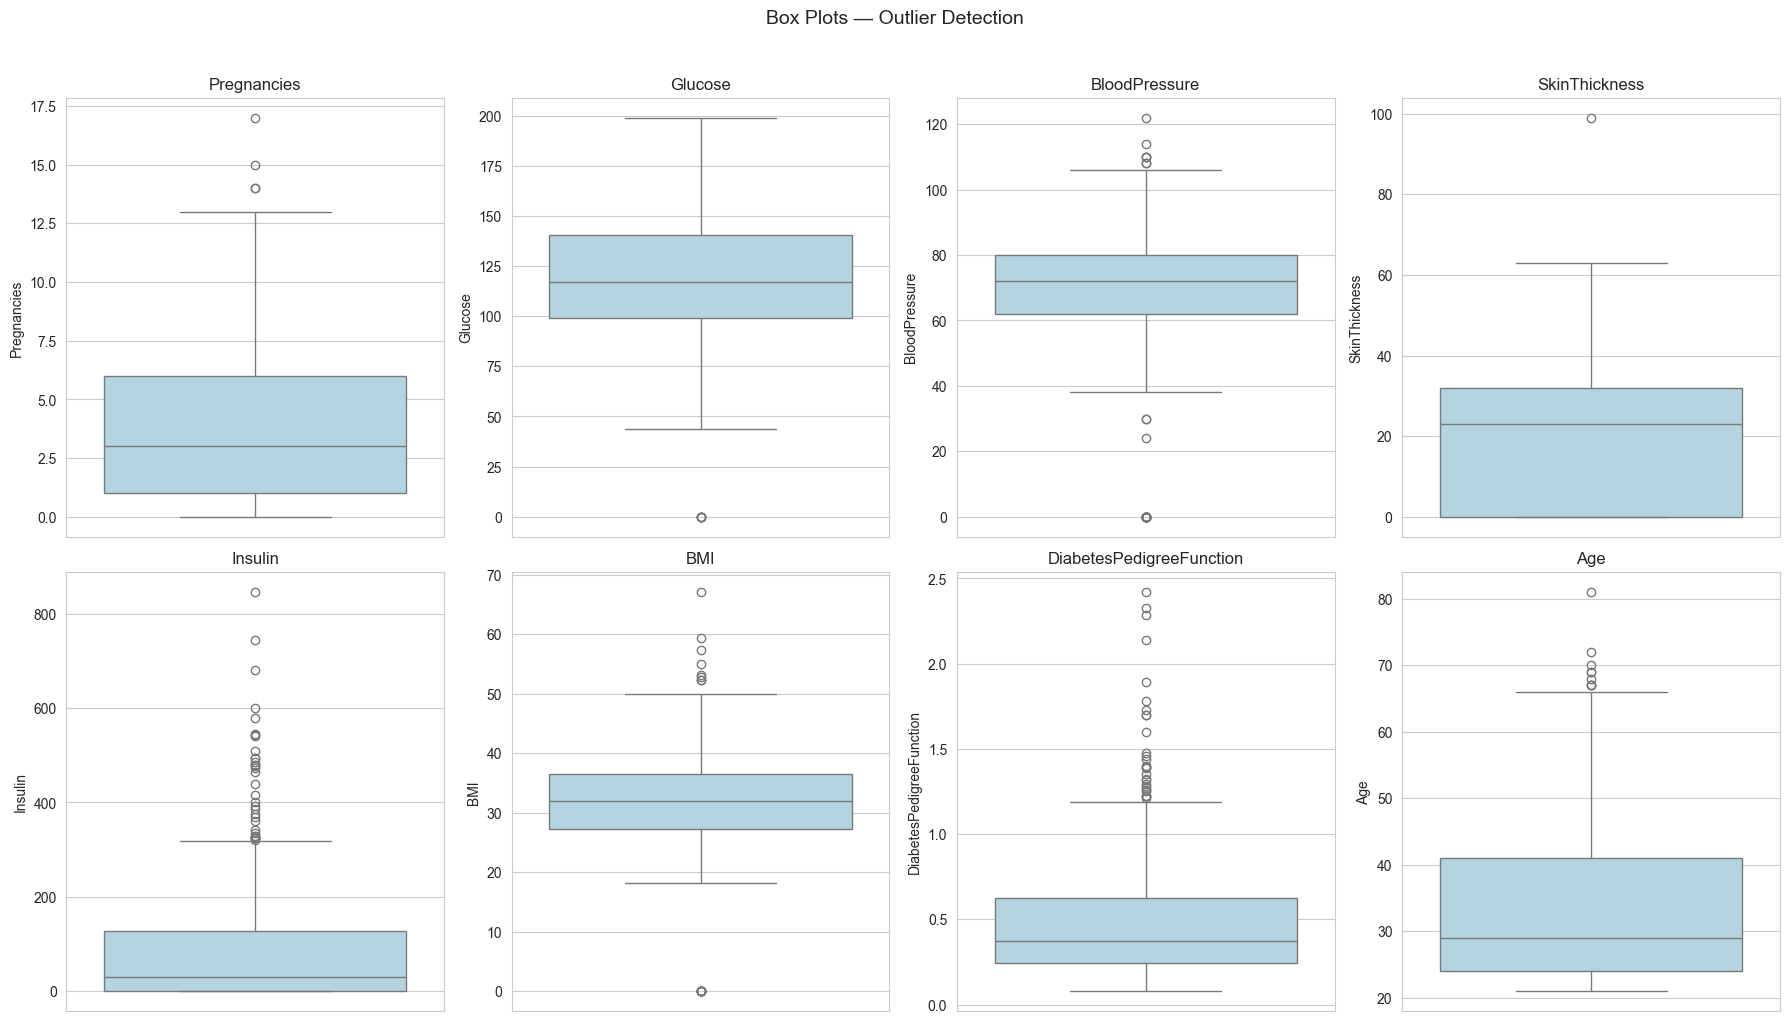

In [ ]:
# Box plots to spot outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    axes[i].set_title(col)

plt.suptitle("Box Plots — Outlier Detection", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 7. Bivariate Analysis — Features vs Outcome

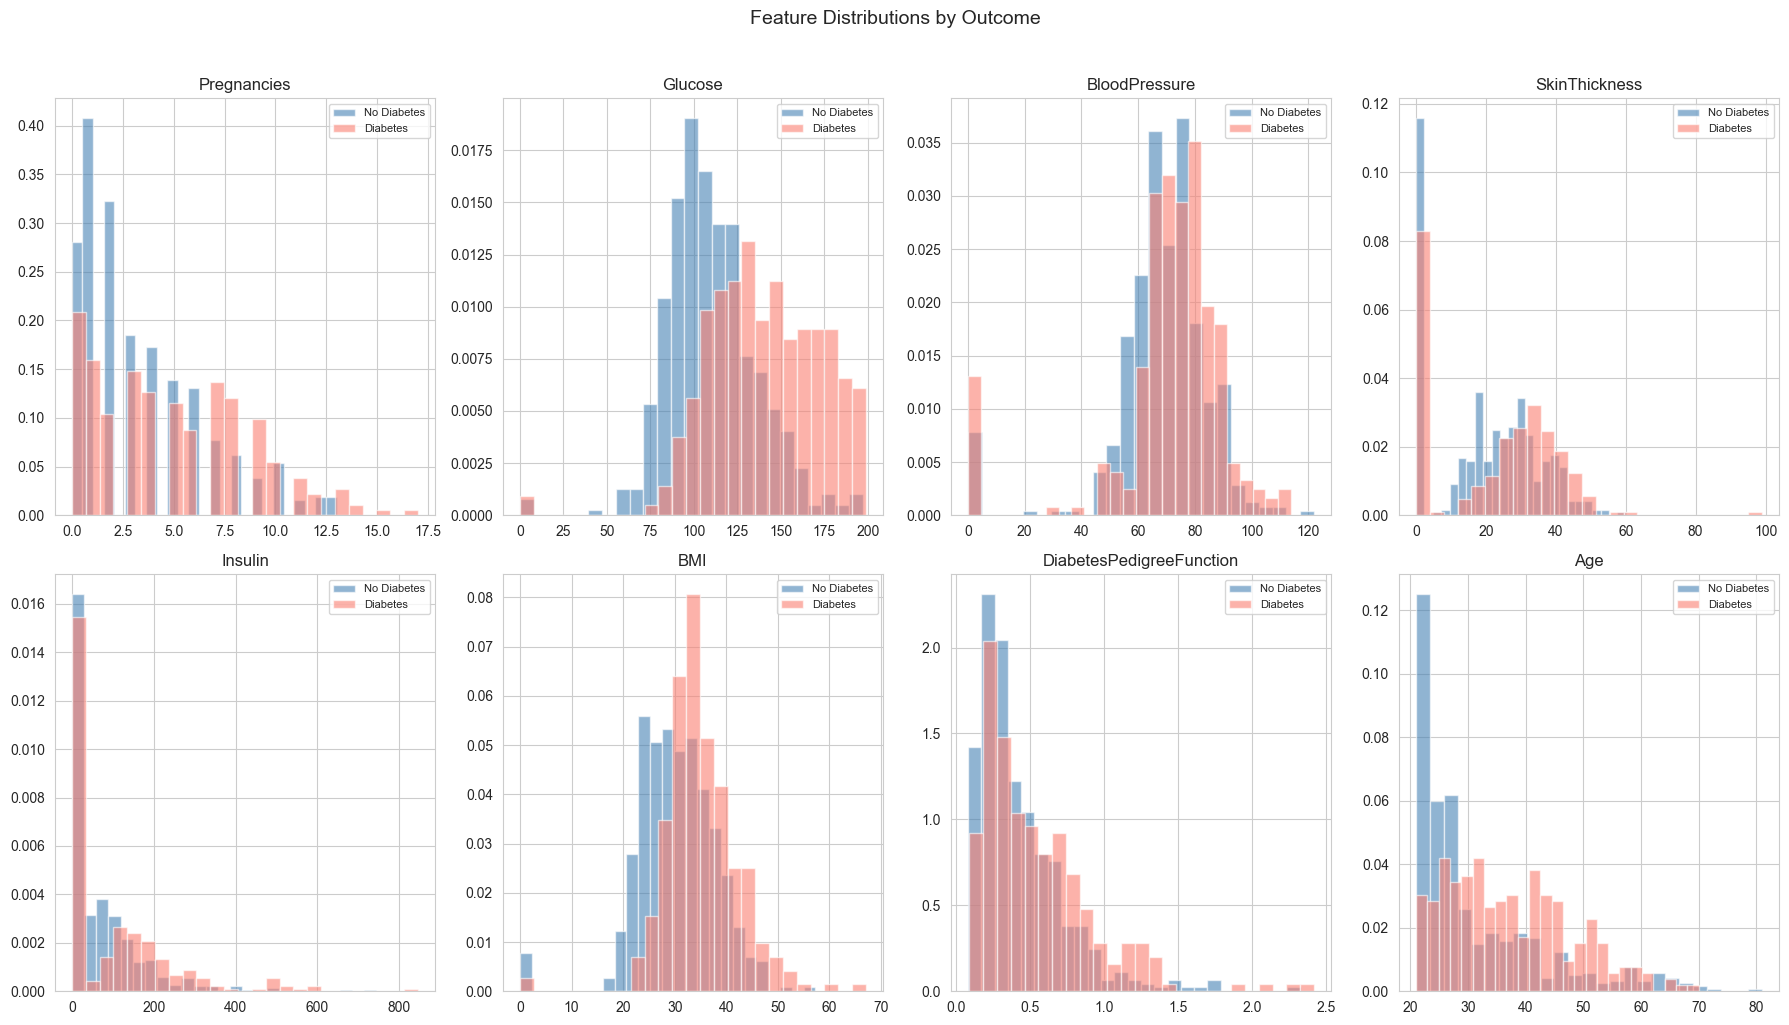

In [ ]:
# Distribution of each feature split by outcome
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    for outcome, color, label in [(0, "steelblue", "No Diabetes"), (1, "salmon", "Diabetes")]:
        subset = df[df["Outcome"] == outcome][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Distributions by Outcome", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Mean feature values by outcome
comparison = df.groupby("Outcome")[features].mean().T
comparison.columns = ["No Diabetes", "Diabetes"]
comparison["Difference"] = comparison["Diabetes"] - comparison["No Diabetes"]
comparison["% Higher"] = (comparison["Difference"] / comparison["No Diabetes"] * 100).round(1)
comparison.round(2)


,No Diabetes,Diabetes,Difference,% Higher
Pregnancies,3.30,4.87,1.57,47.5
Glucose,109.98,141.26,31.28,28.4
BloodPressure,68.18,70.82,2.64,3.9
SkinThickness,19.66,22.16,2.50,12.7
Insulin,68.79,100.34,31.54,45.9
BMI,30.30,35.14,4.84,16.0
DiabetesPedigreeFunction,0.43,0.55,0.12,28.1
Age,31.19,37.07,5.88,18.8


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_71523/2490985529.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Outcome", y=col, data=df, palette="Set2", ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_71523/2490985529.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Diabetes", "Diabetes"])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_71523/2490985529.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Outcome", y=col, data=df, palette="Set2", ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykerne

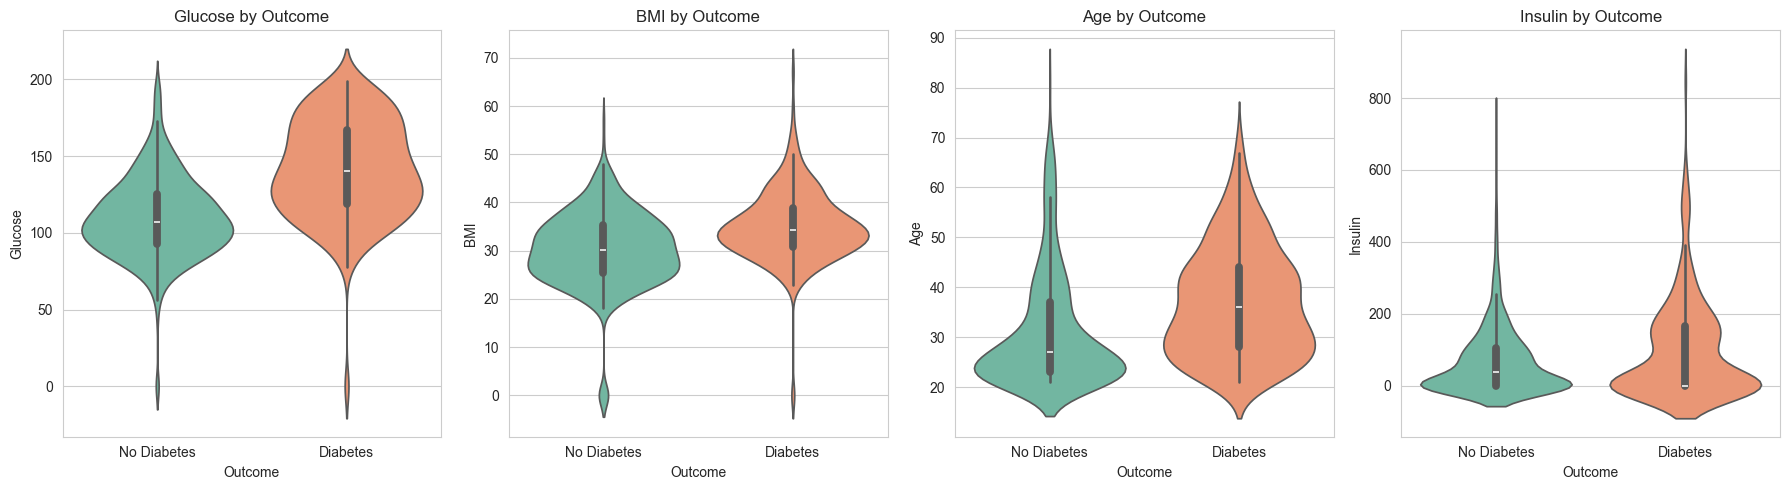

In [ ]:
# Violin plots for key features
key_features = ["Glucose", "BMI", "Age", "Insulin"]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(key_features):
    sns.violinplot(x="Outcome", y=col, data=df, palette="Set2", ax=axes[i])
    axes[i].set_xticklabels(["No Diabetes", "Diabetes"])
    axes[i].set_title(f"{col} by Outcome")

plt.tight_layout()
plt.show()


## 8. Correlation Analysis

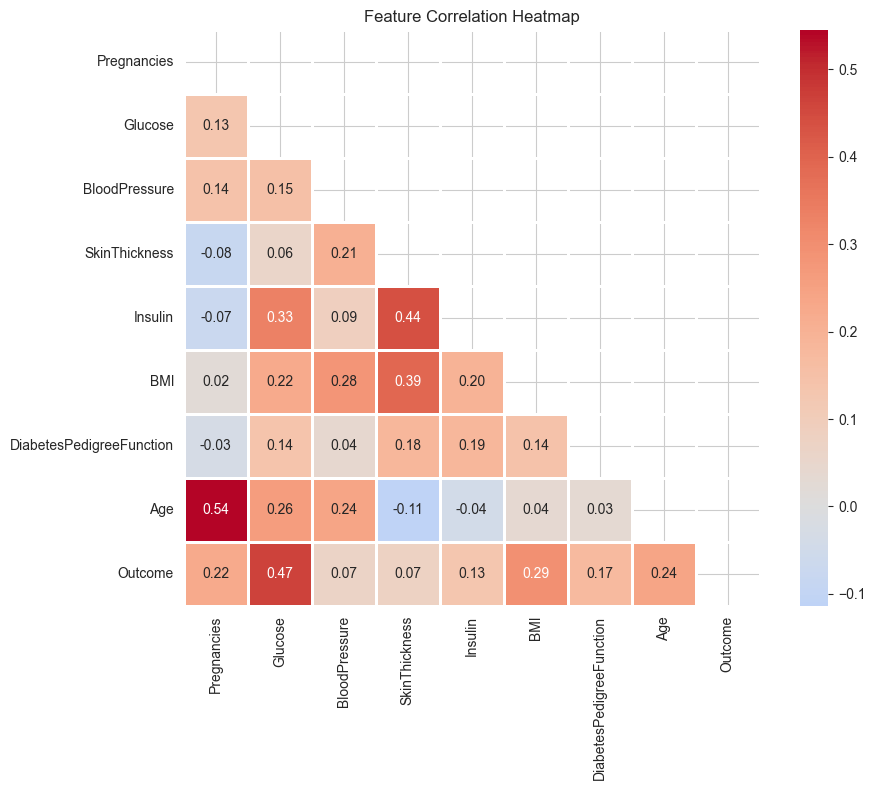

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=1)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


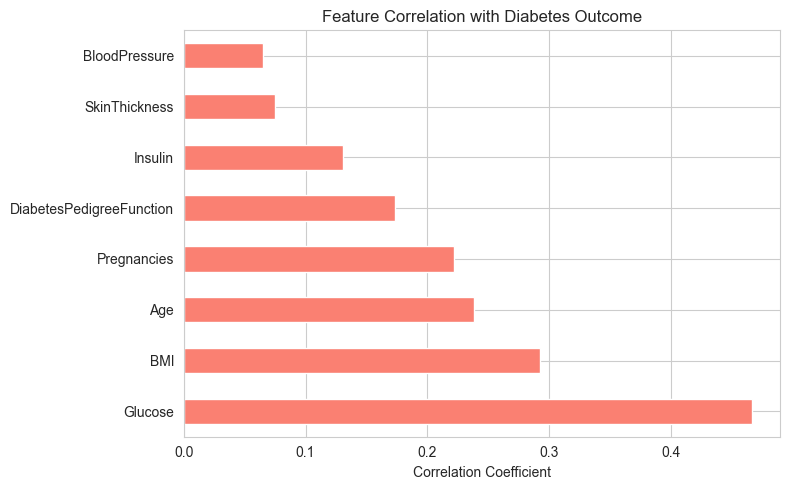

Correlation with Outcome:
Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065
Name: Outcome, dtype: float64


In [ ]:
# Correlation with target
target_corr = df.corr()["Outcome"].drop("Outcome").sort_values(ascending=False)

plt.figure(figsize=(8, 5))
target_corr.plot(kind="barh", color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Feature Correlation with Diabetes Outcome")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

print("Correlation with Outcome:")
print(target_corr.round(3))


## 9. Age and Pregnancy Analysis

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_71523/573116940.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_diabetes = df.groupby("AgeGroup")["Outcome"].mean() * 100
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_71523/573116940.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preg_diabetes = df.groupby("Preg_Group")["Outcome"].mean() * 100


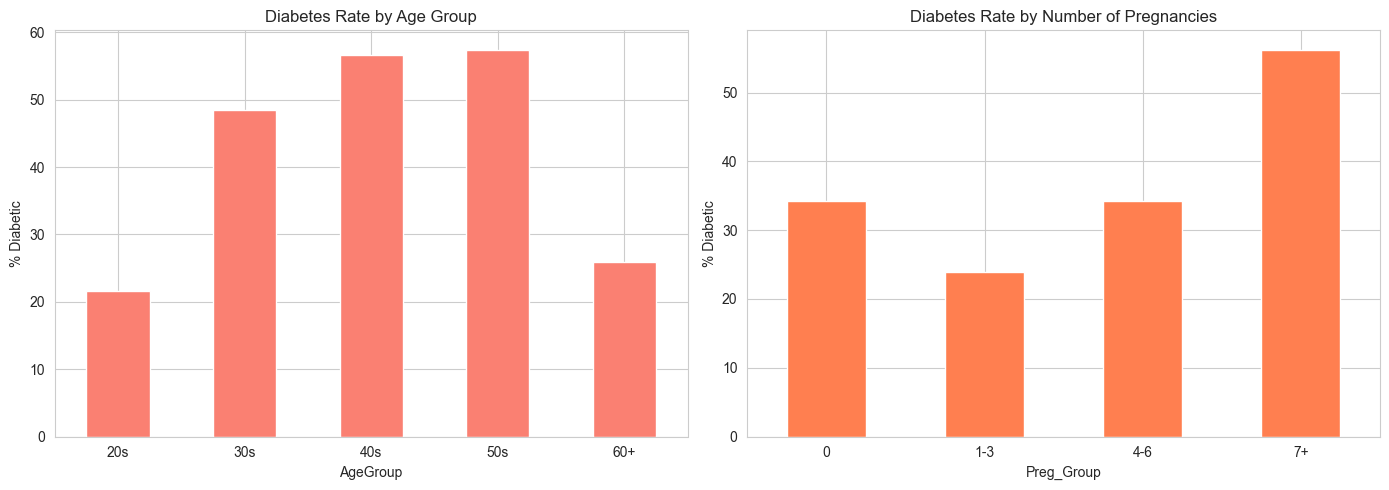

In [ ]:
# Diabetes rate by age group
df["AgeGroup"] = pd.cut(df["Age"], bins=[20, 30, 40, 50, 60, 90], labels=["20s", "30s", "40s", "50s", "60+"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diabetes rate by age group
age_diabetes = df.groupby("AgeGroup")["Outcome"].mean() * 100
age_diabetes.plot(kind="bar", color="salmon", ax=axes[0])
axes[0].set_title("Diabetes Rate by Age Group")
axes[0].set_ylabel("% Diabetic")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Diabetes rate by pregnancy count
df["Preg_Group"] = pd.cut(df["Pregnancies"], bins=[-1, 0, 3, 6, 20], labels=["0", "1-3", "4-6", "7+"])
preg_diabetes = df.groupby("Preg_Group")["Outcome"].mean() * 100
preg_diabetes.plot(kind="bar", color="coral", ax=axes[1])
axes[1].set_title("Diabetes Rate by Number of Pregnancies")
axes[1].set_ylabel("% Diabetic")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Drop temporary columns
df.drop(columns=["AgeGroup", "Preg_Group"], inplace=True)


## 10. Glucose & BMI Deep Dive

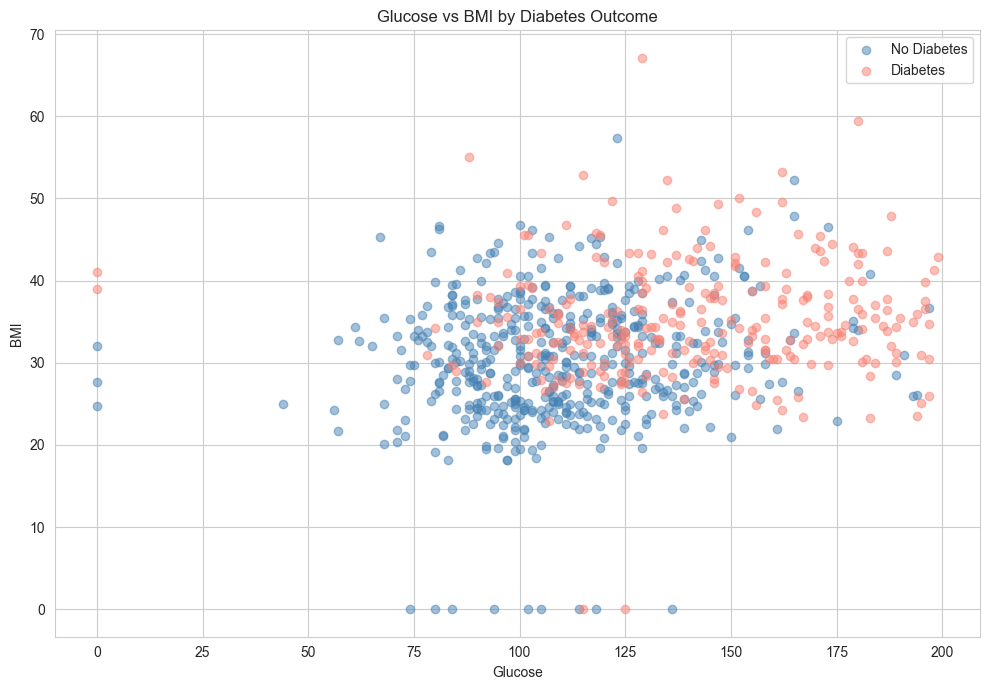

In [ ]:
# Scatter plot: Glucose vs BMI colored by Outcome
plt.figure(figsize=(10, 7))
colors = {0: "steelblue", 1: "salmon"}
for outcome in [0, 1]:
    subset = df[df["Outcome"] == outcome]
    plt.scatter(subset["Glucose"], subset["BMI"], 
                c=colors[outcome], alpha=0.5, 
                label="Diabetes" if outcome else "No Diabetes")

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI by Diabetes Outcome")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Glucose thresholds
print("Diabetes rate by glucose level:")
print("-" * 40)
for label, low, high in [("Normal (<100)", 0, 100), ("Prediabetes (100-126)", 100, 126), ("Diabetes (>126)", 126, 300)]:
    subset = df[(df["Glucose"] >= low) & (df["Glucose"] < high)]
    rate = subset["Outcome"].mean() * 100
    print(f"  {label:25s}: {rate:.1f}% (n={len(subset)})")


Diabetes rate by glucose level:
----------------------------------------
  Normal (<100)            : 8.1% (n=197)
  Prediabetes (100-126)    : 27.7% (n=274)
  Diabetes (>126)          : 59.3% (n=297)


## 11. Pair Plot

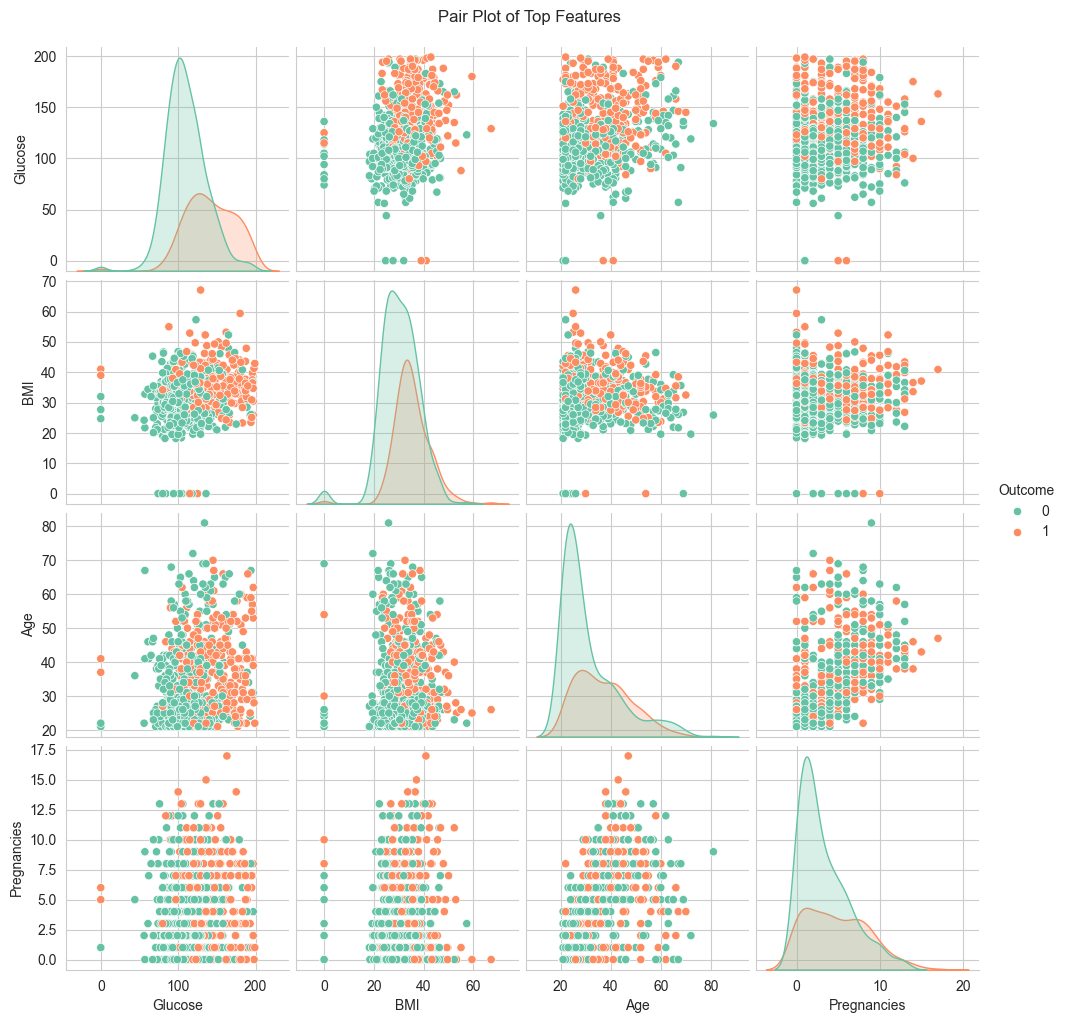

In [ ]:
# Pair plot for top correlated features
top_features = ["Glucose", "BMI", "Age", "Pregnancies", "Outcome"]
sns.pairplot(df[top_features], hue="Outcome", palette="Set2", diag_kind="kde")
plt.suptitle("Pair Plot of Top Features", y=1.02)
plt.show()


## 12. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **Class imbalance**: ~35% diabetic vs ~65% non-diabetic |
| 2 | **Missing values**: Insulin (49%), SkinThickness (30%), BloodPressure, BMI, Glucose have 0s that are actually missing |
| 3 | **Glucose is the strongest predictor** — highest correlation with outcome (~0.47) |
| 4 | **BMI matters**: Obese patients (BMI > 30) have significantly higher diabetes rates |
| 5 | **Age effect**: Diabetes rate increases with age — 60+ group has the highest rate |
| 6 | **Pregnancies**: More pregnancies correlate with higher diabetes risk |
| 7 | **Insulin and SkinThickness** have the most missing values — need careful imputation |
| 8 | **Outliers**: Insulin and DiabetesPedigreeFunction have notable outliers |
| 9 | **Feature interactions**: Glucose + BMI together provide good class separation |